In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ftfy corrige automáticamente texto mal decodificado (mojibake), típico cuando
try:
    import ftfy
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "ftfy", "--quiet"])
    import ftfy

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


## 1. Carga y diagnóstico inicial

In [ ]:
RUTA_ARCHIVO = "Base_de_Leads.xlsx"

df_raw = pd.read_excel(RUTA_ARCHIVO)
df = df_raw.copy()

print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head()


Filas: 210  |  Columnas: 14


,Fecha de Alta,Mes Lead,AgLead,Titulo,Nombre,Telefono,Correo,Producto,Temperatura,Comentario,Asesor,Fuente,Origen,
0,2025-11-30 08:38:00,11,834956f716e7ddae82527bf81c29ebc8,Lead ANGE,Apolonio Torres Perez,NaN,NaN,EMZOOM,Lead Muy Interesado,Se reactiva lead para captura de ventaFinal:EM...,CESAR DE JESUS PESTAÃ‘A,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,1 Ventas
1,2025-11-29 21:17:00,11,13ee2f21ed8506825e8591bf1abdab51,Lead ANGE,Javier Nieto,NaN,NaN,GS4 MAX,Lead Interes Medio,SE LE CONTACTA EN PLAZA ANGELOPOLIS Final:GS4 ...,MAURICIO ALFREDO VAZQUEZ FARFAN,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Finalizado
2,2025-11-29 20:48:00,11,fad33b39f526b4ebe04a4b7e86002d5a,Lead ANGE,Ismael Segovia Banos,NaN,NaN,GS4 MAX,Lead Muy Interesado,SE INTERESA POR GS4 Final:GS4 MAX HEV,MAURICIO ALFREDO VAZQUEZ FARFAN,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,1 Ventas
3,2025-11-29 16:11:00,11,e495cd540b7c7dc55b516fbdc7ea8bf0,Lead ANGE,Luis Jaime Estrada,NaN,NaN,EMKOO,Lead Muy Interesado,ofrecÃ­ tambiÃ©n GS4 y emko hv Pidieron:EMKOO HEV,RICARDO SILVA HERAS,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Contactado
4,2025-11-29 16:08:00,11,4d2b212032284fa42fa64a493e34c4ed,Lead ANGE,Hector Hamley,NaN,NaN,EMKOO,Lead Interes Medio,interÃ©s Pidieron:EMKOO HEV,RICARDO SILVA HERAS,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Contactado


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Fecha de Alta  210 non-null    datetime64[ns]
 1   Mes Lead       210 non-null    int64         
 2   AgLead         210 non-null    object        
 3   Titulo         210 non-null    object        
 4   Nombre         210 non-null    object        
 5   Telefono       0 non-null      float64       
 6   Correo         0 non-null      float64       
 7   Producto       196 non-null    object        
 8   Temperatura    210 non-null    object        
 9   Comentario     210 non-null    object        
 10  Asesor         210 non-null    object        
 11  Fuente         210 non-null    object        
 12  Origen         210 non-null    object        
 13                 210 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(10)
memory usage: 23.1+

## 2. Análisis exploratorio de nulos

Primero se cuantifica el faltante por columna y se observa si existe un patrón en los nulos concentrados en
columnas completas, correlacionados con otra variable, etc. De modo que el mecanismo de pérdida de información
(MCAR, MAR, MNAR) nos permita determinar el método de imputación correcto


In [ ]:
nulos = pd.DataFrame({
    "n_nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str),
    "valores_unicos": df.nunique()
}).sort_values("pct_nulos", ascending=False)

nulos


,n_nulos,pct_nulos,dtype,valores_unicos
Telefono,210,100.00,float64,0
Correo,210,100.00,float64,0
Producto,14,6.67,object,7
AgLead,0,0.00,object,210
Mes Lead,0,0.00,int64,1
Fecha de Alta,0,0.00,datetime64[ns],207
Nombre,0,0.00,object,210
Titulo,0,0.00,object,2
Temperatura,0,0.00,object,3
Comentario,0,0.00,object,169


Buscamos de manera visual la cantidad de nulos en las columnas de interés

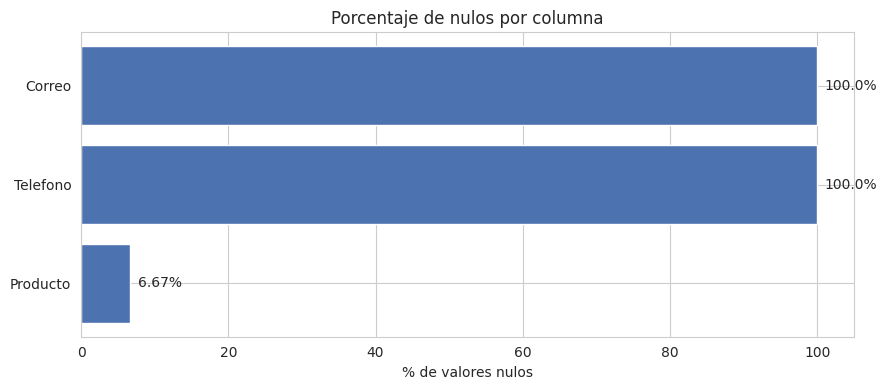

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
nulos_plot = nulos[nulos["n_nulos"] > 0].sort_values("pct_nulos")
ax.barh(nulos_plot.index, nulos_plot["pct_nulos"], color="#4C72B0")
ax.set_xlabel("% de valores nulos")
ax.set_title("Porcentaje de nulos por columna")
for i, v in enumerate(nulos_plot["pct_nulos"]):
    ax.text(v + 1, i, f"{v}%", va="center")
plt.tight_layout()
plt.show()


Buscamos con una matriz binaria de nulos, ver si los nulos de una columna coinciden con los de otra o si son independientes

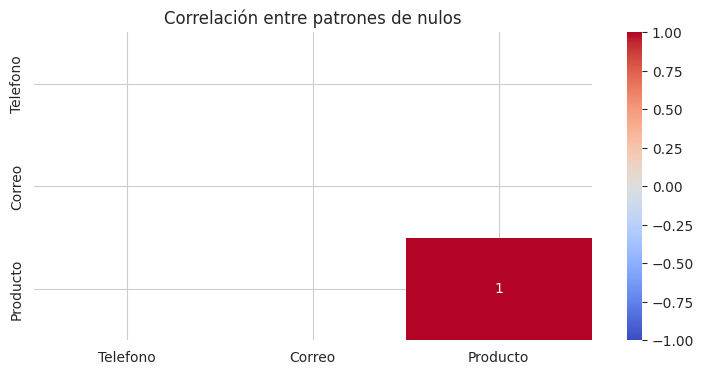

In [ ]:
nulos_bin = df.isna().astype(int)
cols_con_nulos = nulos_bin.columns[nulos_bin.sum() > 0]

if len(cols_con_nulos) > 1:
    corr_nulos = nulos_bin[cols_con_nulos].corr()
    sns.heatmap(corr_nulos, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title("Correlación entre patrones de nulos")
    plt.show()
else:
    print("Solo una columna con nulos parciales; no aplica correlación de patrones.")


Los nulos en Telefono y correo son el 100% en ambas columnas, debido a que no existe un solo valor, no considero que sea relevante para ningún análsis o imputación. Considero que eliminarlas es la mejor alternativa.

Por otro lado, la variable Producto cuenta con un 6.7% de nulos (14 de 210), considero que es la única columna con nulos parciales genuinos y realmente se podría hacer una imputación, se hará un análsis más abajo si el texto de Comentario permite recuperar el dato  antes deecidir una categoría de reemplazo.

Por ultimo, el resto de columnas no tiene nulos, pero sí problemas de calidad de texto (codificación, espacios, mayúsculas inconsistentes) que deben resolverse antes de cualquier análisis posterior, incluido el propio tratamiento de nulos (para poder agrupar correctamente por Asesor).


## 3. Tratamiento de los datos en texto

Antes de hacer una imputación, considero que por la naturaleza de la base de datos, debería de hacer una correcta limpieza y tratamiento de los datos. Al ser una base con comentatios y nombres, tiende a tener columnas vacías o mal etiquetadas, espacios, y errores de ortografía, así como otros errores de captura. Esto podría llegar a afecta directamente el conteo de
categorías reales (dos textos que deberían ser la misma categoría pueden aparecer como distintas por un espacio extra o una mala codificación).


In [ ]:
# Nombres de columnas, hay una columna sin nombre (espacio en blanco) que en realidad contiene el estatus del lead.
print("Columnas originales:")
print(list(df.columns))
print()
print("Valores de la columna sin nombre:")
print(df[" "].value_counts())


Columnas originales:
['Fecha de Alta', 'Mes Lead', 'AgLead', 'Titulo', 'Nombre', 'Telefono', 'Correo', 'Producto', 'Temperatura', 'Comentario', 'Asesor', 'Fuente', 'Origen', ' ']

Valores de la columna sin nombre:
 
Finalizado    123
Contactado     77
1 Ventas       10
Name: count, dtype: int64


In [ ]:
df = df.rename(columns={
    " ": "Estatus",
    "AgLead": "ID_Lead",
})
df.columns = [c.strip() for c in df.columns]
print(list(df.columns))


['Fecha de Alta', 'Mes Lead', 'ID_Lead', 'Titulo', 'Nombre', 'Telefono', 'Correo', 'Producto', 'Temperatura', 'Comentario', 'Asesor', 'Fuente', 'Origen', 'Estatus']


In [ ]:
# 3.2 Detección de patrones típicos como 'Ã' seguido de otro caracter que indiquen una codificación mal interpretada.
patron_mojibake = re.compile(r"Ã.")

cols_texto = df.select_dtypes(include="object").columns.tolist()
reporte_mojibake = {}
for c in cols_texto:
    n = df[c].astype(str).str.contains(patron_mojibake, regex=True, na=False).sum()
    if n > 0:
        reporte_mojibake[c] = n

reporte_mojibake


{'Comentario': np.int64(53), 'Asesor': np.int64(66)}

In [ ]:
# Corrección visual
ejemplos = df.loc[df["Asesor"].astype(str).str.contains(patron_mojibake, na=False), "Asesor"].unique()
for e in ejemplos:
    print(f"{e!r:45s} ->  {ftfy.fix_text(e)!r}")


'CESAR DE JESUS PESTAÃ‘A'                     ->  'CESAR DE JESUS PESTAÑA'
'Alan GonzÃ¡lez Belanzate'                    ->  'Alan González Belanzate'
'Pedro  GonzÃ¡les EspÃ\xadndol'               ->  'Pedro  Gonzáles Espíndol'


In [ ]:
def limpiar_texto(valor):
    """Corrige encoding (mojibake) y normaliza espacios en un texto libre."""
    if pd.isna(valor):
        return valor
    texto = ftfy.fix_text(str(valor))
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

for col in ["Nombre", "Asesor", "Comentario", "Titulo", "Producto",
            "Temperatura", "Fuente", "Origen", "Estatus"]:
    df[col] = df[col].apply(limpiar_texto)

# Verificación: ya no debería haber mojibake
restante = sum(df[c].astype(str).str.contains(patron_mojibake, regex=True, na=False).sum()
               for c in cols_texto if c in df.columns)
print("Ocurrencias de mojibake restantes:", restante)


Ocurrencias de mojibake restantes: 0


In [ ]:
# Caracteres '?' sueltos en Comentario
con_signo_interrogacion = df["Comentario"].str.contains(r"\w\?\w", regex=True, na=False)
print(f"Comentarios con posible pérdida irreversible de acentos: {con_signo_interrogacion.sum()}")
df.loc[con_signo_interrogacion, "Comentario"].head()


Comentarios con posible pérdida irreversible de acentos: 5


,Comentario
41,quiere cotizaci?n y posible prueba de manejo.
156,informaci?n
158,informaci?n
159,informaci?n
161,informaci?n


## 4. Análisis de distribución para decidir el método de imputación


In [ ]:
cols_sin_informacion = [c for c in df.columns if df[c].isna().mean() == 1.0]
print("Columnas 100% nulas:", cols_sin_informacion)


Columnas 100% nulas: ['Telefono', 'Correo']


Aquí, vemos si cómo se encuentra la columna Producto su distribución y posible recuperación desde Comentario

Producto
EMZOOM                       107
EMKOO                         76
NaN                           14
GS8                            7
GS4 MAX                        2
No envian producto valido      2
GN8                            1
AION                           1
Name: count, dtype: int64


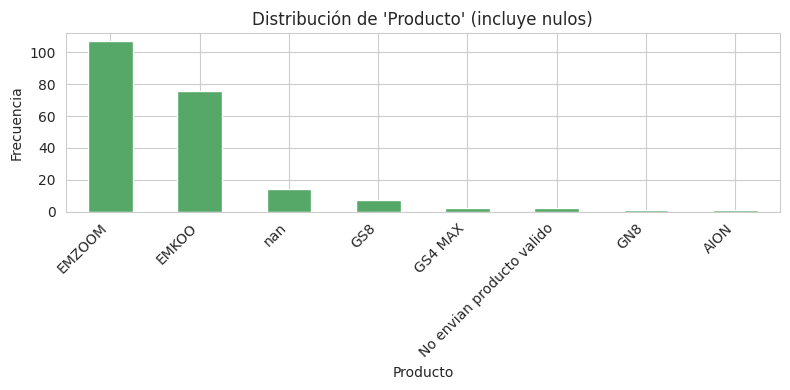

In [ ]:
orden_producto = df["Producto"].value_counts(dropna=False)
print(orden_producto)

fig, ax = plt.subplots(figsize=(8, 4))
orden_producto.plot(kind="bar", color="#55A868", ax=ax)
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de 'Producto' (incluye nulos)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
# Vemo si los comentarios traen un patrón recuperable tipo Pidieron o Final
patron_producto = re.compile(r"(?:Pidieron|Final)\s*:\s*(.+)", re.IGNORECASE)

df["Producto_extraido_comentario"] = df["Comentario"].apply(
    lambda t: (m.group(1).strip() if (m := patron_producto.search(str(t))) else np.nan)
)

filas_nulas_producto = df["Producto"].isna()
print(f"Filas con Producto nulo: {filas_nulas_producto.sum()}")
print("De esas, cuántas tienen un producto recuperable en el comentario:",
      df.loc[filas_nulas_producto, "Producto_extraido_comentario"].notna().sum())

df.loc[filas_nulas_producto, ["Comentario", "Producto_extraido_comentario"]]


Filas con Producto nulo: 14
De esas, cuántas tienen un producto recuperable en el comentario: 0


,Comentario,Producto_extraido_comentario
18,quieren EMZOOM 2026 vienen a verlo el Finde se...,NaN
38,quiere mensualidades entre 5000 a 6000,NaN
39,quiere pagar el enchnche con tarjeta,NaN
41,quiere cotizaci?n y posible prueba de manejo.,NaN
70,Gl Racer,NaN
72,Gl Racer,NaN
118,HEV,NaN
126,Gl Racer,NaN
131,Gl Racer,NaN
156,informaci?n,NaN


Ninguna de las filas con Producto nulo tiene el patrón Pidieron o Final en su
comentario, el asesor simplemente no llegó a capturar el producto de interés (comentarios como "Gl Racer", "informacion", "HEV" sueltos, sin estructura). Por lo que falta porque el proceso de captura no lo registró y no fue al azar.

No pienso que se pueda usar la moda porque inflaría artificialmente la categoría dominante y daría una falsa sensación de certeza sobre el interés del lead.Tampoco se puede recuperar desde Comentario de forma confiable (se intentó y no aplica para estas filas).


In [ ]:
df = df.drop(columns=["Producto_extraido_comentario"])


Las columnas constantes (Fuente, Origen, Mes Lead), no tienen nulos, pero conviene documentarlas en el diagnóstico, tienen un único valor en las 210 filas, no aportan poder discriminante para segmentación dentro de esta base (aunque sí son útiles como metadato).


In [ ]:
for c in ["Fuente", "Origen", "Mes Lead"]:
    print(f"{c}: {df[c].nunique()} valor(es) único(s) -> {df[c].unique()}")


Fuente: 1 valor(es) único(s) -> ['11.Origen Personalizado/Calle']
Origen: 1 valor(es) único(s) -> ['PLAZA ANGELOPOLIS']
Mes Lead: 1 valor(es) único(s) -> [11]


## 5. Pipeline de limpieza reproducible

Se agrupa todo lo anterior en una función única, para poder aplicarla de forma consistente a nuevas
descargas de la misma base (mismo template de exportación del CRM).


In [ ]:
def limpiar_base_leads(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    Limpieza estandarizada para la Base de Leads:
    1. Normaliza nombres de columnas.
    2. Corrige encoding (mojibake) y espacios en texto libre.
    3. Elimina columnas sin ninguna información (100% nulas).
    4. Imputa 'Producto' con categoría explícita 'No especificado' cuando no es recuperable.
    """
    d = df_input.copy()

    # 1. Nombres de columna
    d = d.rename(columns={" ": "Estatus", "AgLead": "ID_Lead"})
    d.columns = [c.strip() for c in d.columns]

    # 2. Texto libre: encoding + espacios
    cols_txt = d.select_dtypes(include="object").columns.tolist()
    for c in cols_txt:
        d[c] = d[c].apply(limpiar_texto)

    # 3. Columnas sin ninguna información (100% nulas)
    cols_vacias = [c for c in d.columns if d[c].isna().mean() == 1.0]
    d = d.drop(columns=cols_vacias)

    # 4. Imputación fundamentada de 'Producto'
    if "Producto" in d.columns:
        patron = re.compile(r"(?:Pidieron|Final)\s*:\s*(.+)", re.IGNORECASE)
        recuperado = d["Comentario"].apply(
            lambda t: (m.group(1).strip() if (m := patron.search(str(t))) else np.nan)
        )
        d["Producto"] = d["Producto"].fillna(recuperado)
        d["Producto"] = d["Producto"].fillna("No especificado")

    return d, cols_vacias


df_limpio, columnas_eliminadas = limpiar_base_leads(df_raw)
print("Columnas eliminadas por no tener ninguna información:", columnas_eliminadas)
df_limpio.head()


Columnas eliminadas por no tener ninguna información: ['Telefono', 'Correo']


,Fecha de Alta,Mes Lead,ID_Lead,Titulo,Nombre,Producto,Temperatura,Comentario,Asesor,Fuente,Origen,Estatus
0,2025-11-30 08:38:00,11,834956f716e7ddae82527bf81c29ebc8,Lead ANGE,Apolonio Torres Perez,EMZOOM,Lead Muy Interesado,Se reactiva lead para captura de ventaFinal:EM...,CESAR DE JESUS PESTAÑA,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,1 Ventas
1,2025-11-29 21:17:00,11,13ee2f21ed8506825e8591bf1abdab51,Lead ANGE,Javier Nieto,GS4 MAX,Lead Interes Medio,SE LE CONTACTA EN PLAZA ANGELOPOLIS Final:GS4 ...,MAURICIO ALFREDO VAZQUEZ FARFAN,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Finalizado
2,2025-11-29 20:48:00,11,fad33b39f526b4ebe04a4b7e86002d5a,Lead ANGE,Ismael Segovia Banos,GS4 MAX,Lead Muy Interesado,SE INTERESA POR GS4 Final:GS4 MAX HEV,MAURICIO ALFREDO VAZQUEZ FARFAN,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,1 Ventas
3,2025-11-29 16:11:00,11,e495cd540b7c7dc55b516fbdc7ea8bf0,Lead ANGE,Luis Jaime Estrada,EMKOO,Lead Muy Interesado,ofrecí también GS4 y emko hv Pidieron:EMKOO HEV,RICARDO SILVA HERAS,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Contactado
4,2025-11-29 16:08:00,11,4d2b212032284fa42fa64a493e34c4ed,Lead ANGE,Hector Hamley,EMKOO,Lead Interes Medio,interés Pidieron:EMKOO HEV,RICARDO SILVA HERAS,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Contactado


## 6. Validación final

In [ ]:
print("ANTES")
print(df_raw.isna().sum())
print()
print("DESPUÉS")
print(df_limpio.isna().sum())


ANTES
Fecha de Alta      0
Mes Lead           0
AgLead             0
Titulo             0
Nombre             0
Telefono         210
Correo           210
Producto          14
Temperatura        0
Comentario         0
Asesor             0
Fuente             0
Origen             0
                   0
dtype: int64

DESPUÉS
Fecha de Alta    0
Mes Lead         0
ID_Lead          0
Titulo           0
Nombre           0
Producto         0
Temperatura      0
Comentario       0
Asesor           0
Fuente           0
Origen           0
Estatus          0
dtype: int64


In [ ]:
print(f"Filas originales: {df_raw.shape[0]}  |  Filas finales: {df_limpio.shape[0]}")
print(f"Columnas originales: {df_raw.shape[1]}  |  Columnas finales: {df_limpio.shape[1]}")
print()
print("Distribución final de 'Producto':")
print(df_limpio["Producto"].value_counts())


Filas originales: 210  |  Filas finales: 210
Columnas originales: 14  |  Columnas finales: 12

Distribución final de 'Producto':
Producto
EMZOOM                       107
EMKOO                         76
No especificado               14
GS8                            7
GS4 MAX                        2
No envian producto valido      2
GN8                            1
AION                           1
Name: count, dtype: int64


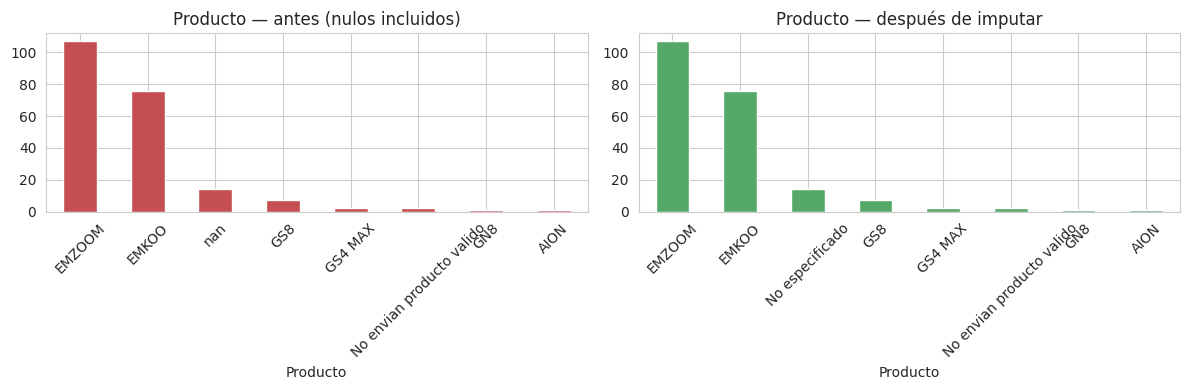

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_raw["Producto"].value_counts(dropna=False).plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("Producto — antes (nulos incluidos)")
axes[0].tick_params(axis="x", rotation=45)

df_limpio["Producto"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Producto — después de imputar")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 7. Exportar base limpia

In [ ]:
RUTA_SALIDA = "Base_de_Leads_limpia.xlsx"
df_limpio.to_excel(RUTA_SALIDA, index=False)
print(f"Base limpia exportada a: {RUTA_SALIDA}")


Base limpia exportada a: Base_de_Leads_limpia.xlsx
